# KSW Estimator Tester

This notebook tests the KSW estimator pipeline using `Initializor` and `Generator` classes.

In [20]:
# Setup logging FIRST to prevent Jupyter double-printing
import logging
import os

# Suppress TensorFlow and CUDA warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # 0=all, 1=info, 2=warning, 3=error
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # Disable GPU

# Configure logging to suppress verbose external packages
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("tensorrt").setLevel(logging.ERROR)

from mlpng.utils import setup_logging

logger = setup_logging(__name__, level=logging.INFO, base_level=logging.WARNING)

## Configuration

Edit these settings to customize the test run.

In [21]:
# Configuration - edit these as needed
CONFIG = {
    "settings_file": "settings/n64.json",
    "nsims": 100,
    "shapes": ["local", "equilateral", "orthogonal"],
    "lensing_options": [False, True],  # Both unlensed and lensed
    "force_generation": True,
    "fnl_min": -1000.0,
    "fnl_max": 1000.0,
    "n_sigma": 5,  # Number of sigma levels to report
}

## Initialize Generator

Set up the `Generator` with cosmology and transfer functions.

In [22]:
import numpy as np
from mlpng.generator import Generator
from mlpng.initializor import Initializor
from mlpng.utils import plot_predictions

# Build command-line style args for Initializor (generates and saves KSW)
# Use 'all' if multiple shapes, otherwise use the single shape name
if len(CONFIG["shapes"]) > 1:
    shapes_arg = "all"
else:
    shapes_arg = CONFIG["shapes"][0]

init_argv = [
    CONFIG["settings_file"],
    "--shapes",
    shapes_arg,
    "--nsims",
    str(CONFIG["nsims"]),
    "--force_generation",  # Always retrain KSW for clean test
    "--lensing" if True in CONFIG["lensing_options"] else "--no-lensing",
]

logger.info("Initializing KSW estimators with Initializor...")
logger.info("Init args: %s", init_argv)
initializer = Initializor(argv=init_argv, log_level=logging.INFO)
initializer.run()
logger.info("KSW estimators saved to: %s", initializer.mc_file)

# Now initialize Generator to load and use KSW estimators
gen_argv = [
    CONFIG["settings_file"],
    "--nsims",
    str(CONFIG["nsims"]),
    "--shapes",
    shapes_arg,
    "--force_generation" if CONFIG["force_generation"] else "--no-force_generation",
    "--lensing" if True in CONFIG["lensing_options"] else "--no-lensing",
]

gen = Generator(argv=gen_argv)
logger.info(
    "Generator initialized: lmax=%d, nside=%d, nsims=%d", gen.lmax, gen.nside, gen.nsims
)

08-Jan-26 11:38:02 - __main__ - INFO - Initializing KSW estimators with Initializor...
08-Jan-26 11:38:02 - __main__ - INFO - Init args: ['settings/n64.json', '--shapes', 'all', '--nsims', '100', '--force_generation', '--lensing']
08-Jan-26 11:38:02 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
08-Jan-26 11:38:02 - __main__ - INFO - Init args: ['settings/n64.json', '--shapes', 'all', '--nsims', '100', '--force_generation', '--lensing']
08-Jan-26 11:38:02 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
08-Jan-26 11:39:35 - root - WARNING - power_spectra_from_transfer with non-linear lensing does not recalculate the non-linear correction
08-Jan-26 11:42:55 - mlpng.initializor - INFO - Finished unlensed local! Saved to data/kswmc/l191_n64_T_100_p1.0_local_unlensed.hdf5
08-Jan-26 11:51:31 - mlpng.initializor - INFO - Finished unlensed equilateral! Saved to data/kswmc/l191_n64_T_100_p1.0_equilateral_unlensed.hdf5
08-Jan-26 12:00:16 - mlpng.initial

## Helper Functions

Define reusable functions for KSW initialization, estimation, and analysis.

In [23]:
def print_sigma_stats(residuals, sigma, n_sigma=5):
    """Print confidence interval statistics."""
    expected = {1: 68.27, 2: 95.45, 3: 99.73, 4: 99.994, 5: 99.99994}

    print(f"\n{'='*60}")
    print(f"Confidence Interval Statistics (σ = {sigma:.4f})")
    print(f"{'='*60}")
    print(f"{'Level':<10} {'Count':<15} {'Percentage':<15} {'Expected':<15}")
    print(f"{'-'*60}")

    for i in range(1, n_sigma + 1):
        within = np.sum(np.abs(residuals) < i * sigma)
        pct = 100 * within / len(residuals)
        exp = expected.get(i, 100.0)
        print(
            f"{i}σ{'':<8} {within}/{len(residuals):<12} {pct:>6.2f}%{'':<8} {exp:>6.2f}%"
        )

    print(f"{'='*60}")
    print(f"Mean residual: {np.mean(residuals):.4f}")
    print(f"Std residual:  {np.std(residuals):.4f}")

## Generate Gaussian ALMs

Generate base Gaussian alms (used for all shape/lensing combinations).

In [24]:
# Generate Gaussian alms using Generator (unlensed base)
logger.info("Generating %d Gaussian alms using Generator...", CONFIG["nsims"])
alm_l = gen.generate_alm()

# Generate random true fnl values (same for all tests)
rng = np.random.default_rng(42)  # Fixed seed for reproducibility
fnl_true = rng.uniform(CONFIG["fnl_min"], CONFIG["fnl_max"], (CONFIG["nsims"], 1, 1))

logger.info("Base ALM data generated: shape=%s", alm_l.shape)

08-Jan-26 12:22:34 - __main__ - INFO - Generating 100 Gaussian alms using Generator...
08-Jan-26 12:22:34 - __main__ - INFO - Base ALM data generated: shape=(100, 3, 18528)


## Run All Shape/Lensing Combinations

Loop through all shapes and lensing options, running KSW estimation for each.

unlensed:   0%|          | 0/3 [00:00<?, ?it/s]


######################################################################
## LOCAL (UNLENSED)
######################################################################
08-Jan-26 12:22:53 - __main__ - INFO - Loading KSW estimator for local (unlensed)...


08-Jan-26 12:23:09 - __main__ - INFO - Generating non-Gaussian alms for local...


alm_nl:   0%|          | 0/100 [00:00<?, ?it/s]

alm_combined shape: (100, 1, 18528)
08-Jan-26 12:25:15 - __main__ - INFO - Fisher: 0.0004, σ: 47.2834

Confidence Interval Statistics (σ = 47.2834)
Level      Count           Percentage      Expected       
------------------------------------------------------------
1σ         46/100           46.00%          68.27%
2σ         74/100           74.00%          95.45%
3σ         91/100           91.00%          99.73%
4σ         98/100           98.00%          99.99%
5σ         99/100           99.00%         100.00%
Mean residual: 3.4619
Std residual:  81.9635
preds shape: (1, 100) truth shape: (1, 100)


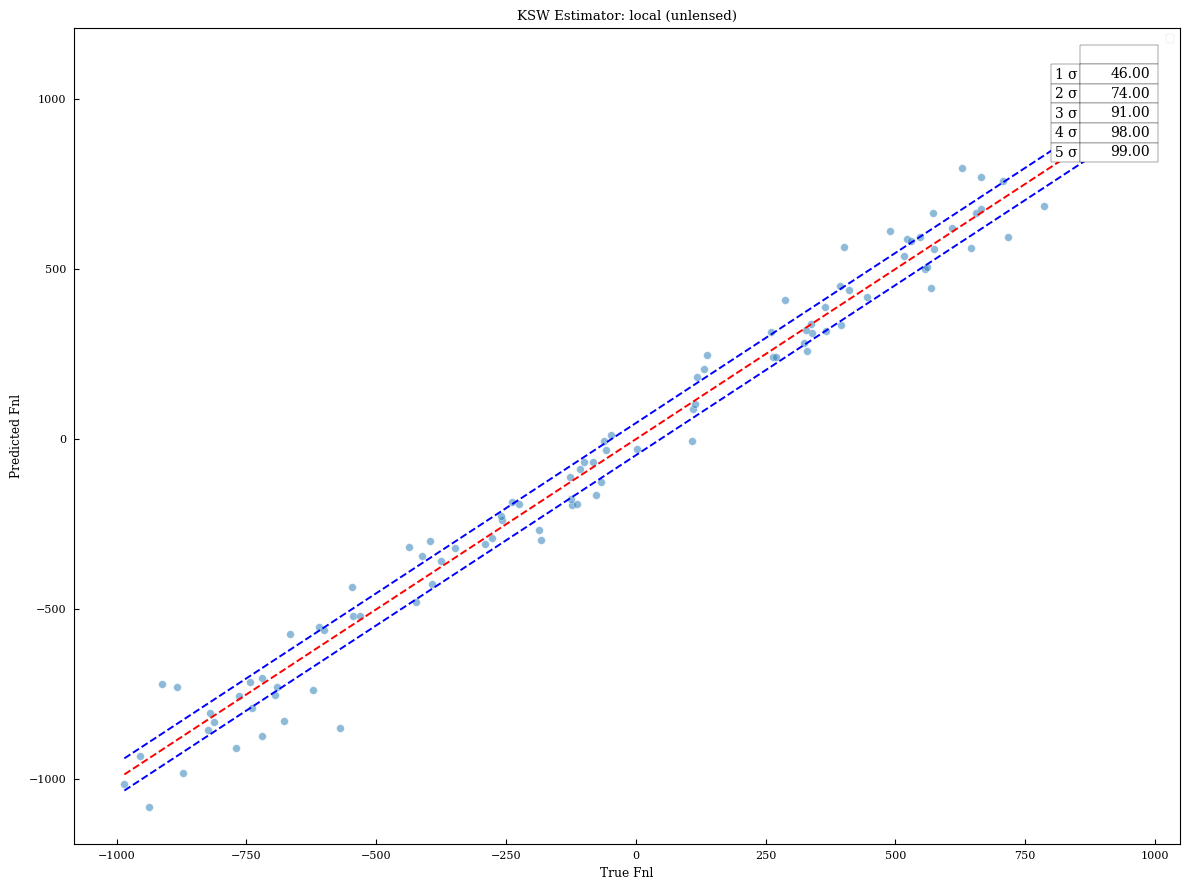


######################################################################
## EQUILATERAL (UNLENSED)
######################################################################
08-Jan-26 12:25:48 - __main__ - INFO - Loading KSW estimator for equilateral (unlensed)...
08-Jan-26 12:26:08 - __main__ - INFO - Generating non-Gaussian alms for equilateral...


alm_ng equilateral:   0%|          | 0/100 [00:00<?, ?it/s]

alm_combined shape: (100, 1, 18528)
08-Jan-26 12:28:41 - __main__ - INFO - Fisher: 0.0000, σ: 309.5494

Confidence Interval Statistics (σ = 309.5494)
Level      Count           Percentage      Expected       
------------------------------------------------------------
1σ         73/100           73.00%          68.27%
2σ         93/100           93.00%          95.45%
3σ         100/100          100.00%          99.73%
4σ         100/100          100.00%          99.99%
5σ         100/100          100.00%         100.00%
Mean residual: 48.0343
Std residual:  317.1601
preds shape: (1, 100) truth shape: (1, 100)


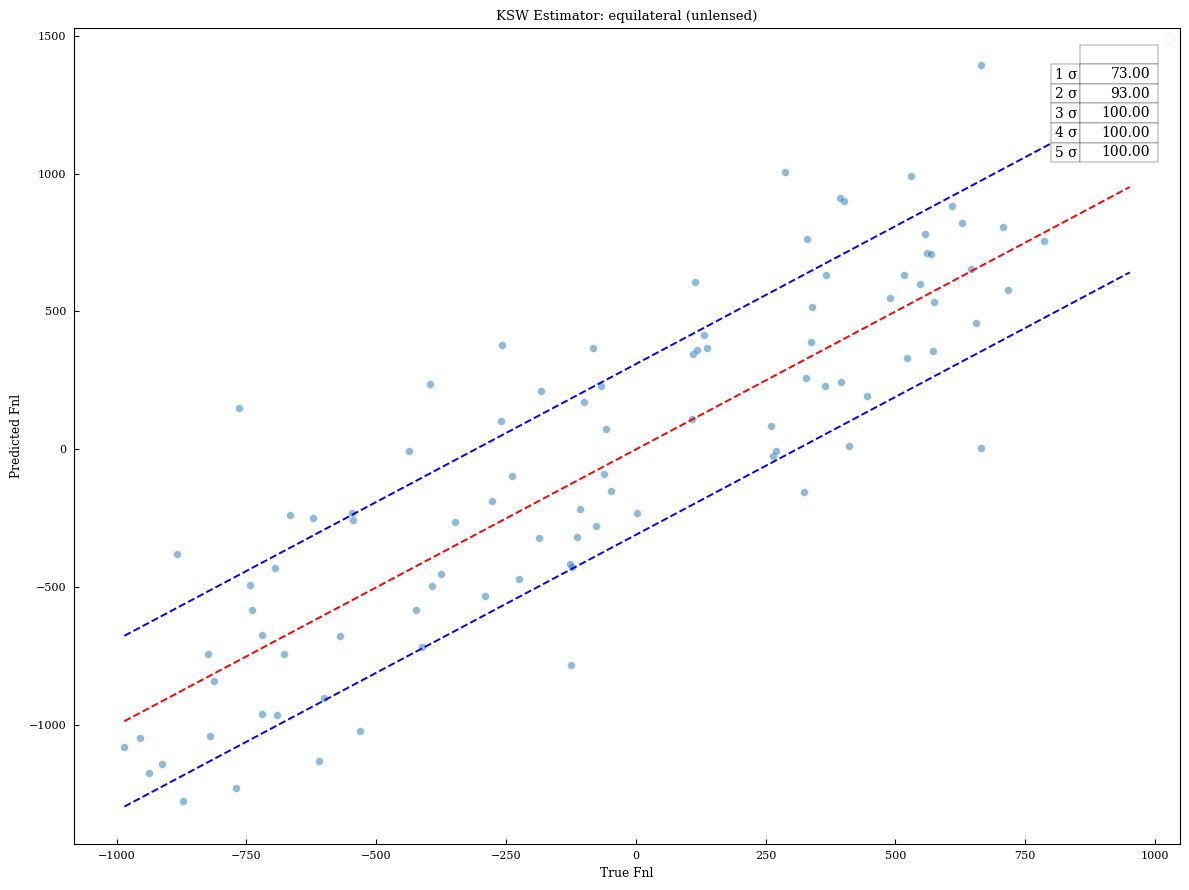


######################################################################
## ORTHOGONAL (UNLENSED)
######################################################################
08-Jan-26 12:29:55 - __main__ - INFO - Loading KSW estimator for orthogonal (unlensed)...
08-Jan-26 12:30:14 - __main__ - INFO - Generating non-Gaussian alms for orthogonal...


alm_ng orthogonal:   0%|          | 0/100 [00:00<?, ?it/s]

alm_combined shape: (100, 1, 18528)
08-Jan-26 12:32:52 - __main__ - INFO - Fisher: 0.0000, σ: 164.7939

Confidence Interval Statistics (σ = 164.7939)
Level      Count           Percentage      Expected       
------------------------------------------------------------
1σ         64/100           64.00%          68.27%
2σ         94/100           94.00%          95.45%
3σ         100/100          100.00%          99.73%
4σ         100/100          100.00%          99.99%
5σ         100/100          100.00%         100.00%
Mean residual: -0.1513
Std residual:  168.3568
preds shape: (1, 100) truth shape: (1, 100)


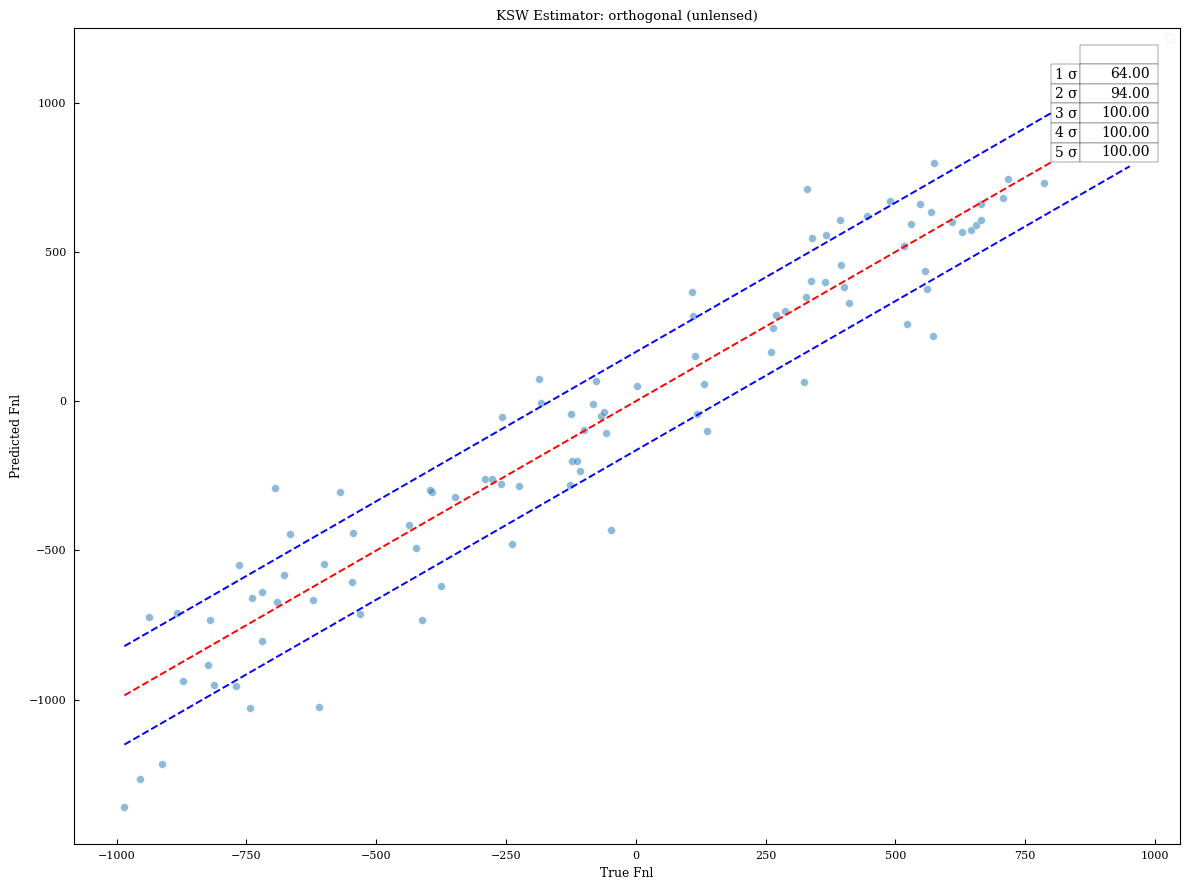

lensed:   0%|          | 0/3 [00:00<?, ?it/s]


######################################################################
## LOCAL (LENSED)
######################################################################
08-Jan-26 12:34:01 - __main__ - INFO - Loading KSW estimator for local (lensed)...
08-Jan-26 12:34:16 - __main__ - INFO - Generating non-Gaussian alms for local...


alm_nl:   0%|          | 0/100 [00:00<?, ?it/s]

alm_combined shape: (100, 1, 18528)
08-Jan-26 12:36:24 - __main__ - INFO - Fisher: 0.0004, σ: 47.1737

Confidence Interval Statistics (σ = 47.1737)
Level      Count           Percentage      Expected       
------------------------------------------------------------
1σ         34/100           34.00%          68.27%
2σ         62/100           62.00%          95.45%
3σ         85/100           85.00%          99.73%
4σ         92/100           92.00%          99.99%
5σ         96/100           96.00%         100.00%
Mean residual: 5.8984
Std residual:  105.9454
preds shape: (1, 100) truth shape: (1, 100)


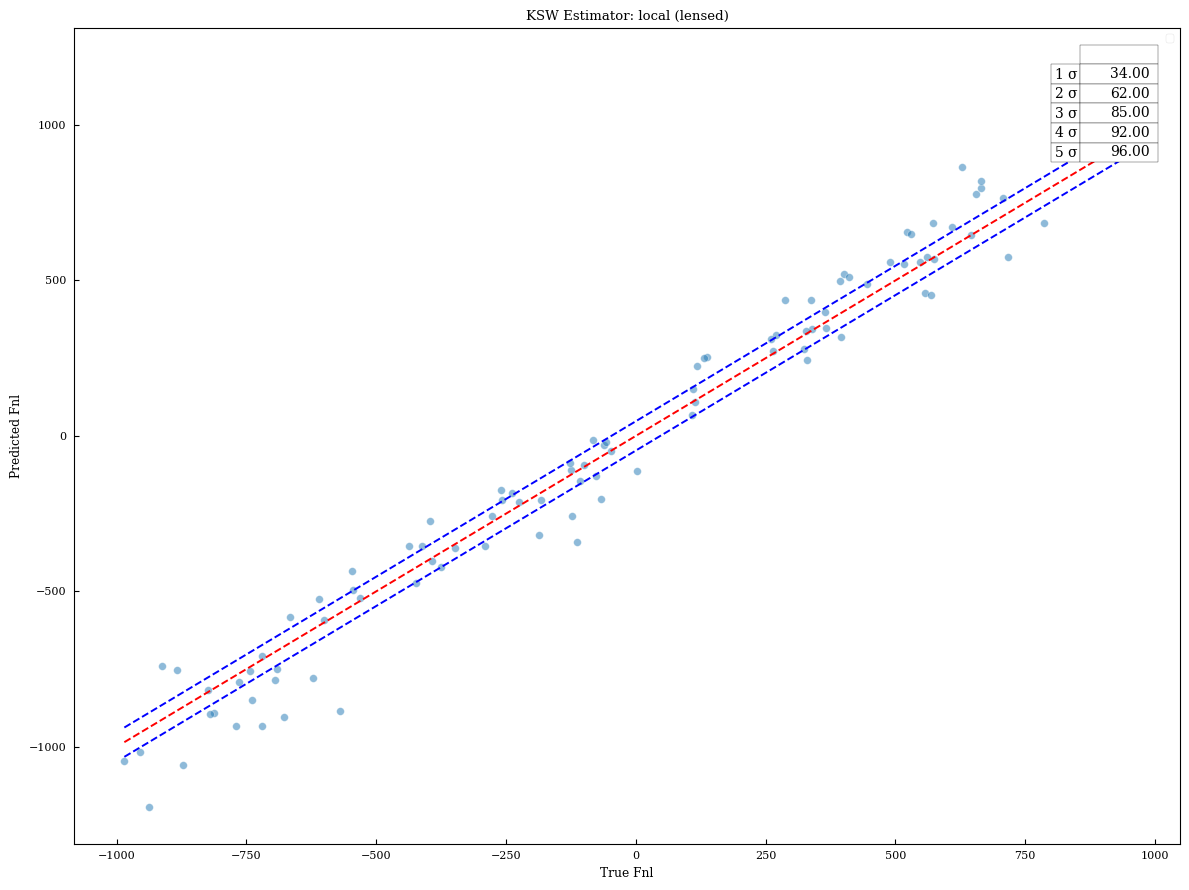


######################################################################
## EQUILATERAL (LENSED)
######################################################################
08-Jan-26 12:36:57 - __main__ - INFO - Loading KSW estimator for equilateral (lensed)...
08-Jan-26 12:37:16 - __main__ - INFO - Generating non-Gaussian alms for equilateral...


alm_ng equilateral:   0%|          | 0/100 [00:00<?, ?it/s]

alm_combined shape: (100, 1, 18528)
08-Jan-26 12:39:51 - __main__ - INFO - Fisher: 0.0000, σ: 309.6725

Confidence Interval Statistics (σ = 309.6725)
Level      Count           Percentage      Expected       
------------------------------------------------------------
1σ         62/100           62.00%          68.27%
2σ         95/100           95.00%          95.45%
3σ         99/100           99.00%          99.73%
4σ         100/100          100.00%          99.99%
5σ         100/100          100.00%         100.00%
Mean residual: 60.9966
Std residual:  324.2320
preds shape: (1, 100) truth shape: (1, 100)


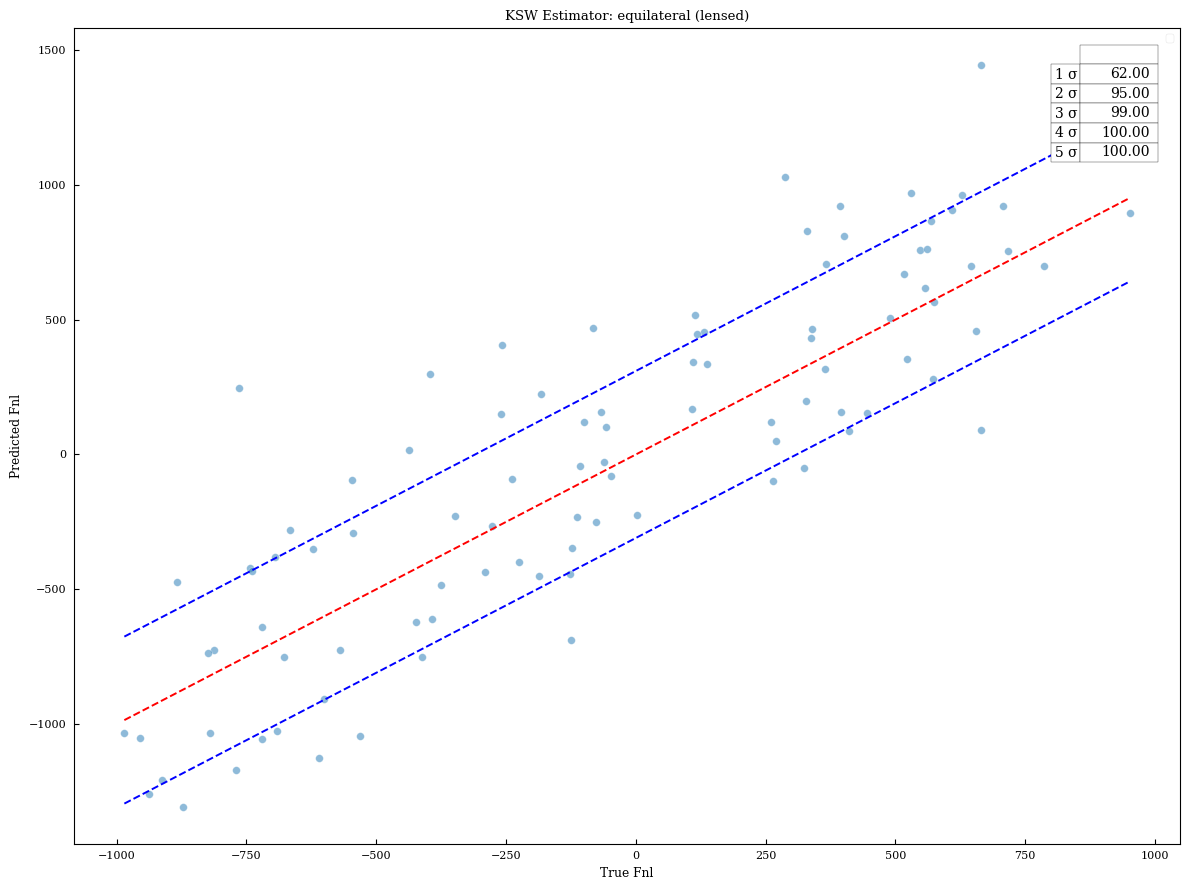


######################################################################
## ORTHOGONAL (LENSED)
######################################################################
08-Jan-26 12:40:57 - __main__ - INFO - Loading KSW estimator for orthogonal (lensed)...
08-Jan-26 12:41:15 - __main__ - INFO - Generating non-Gaussian alms for orthogonal...


alm_ng orthogonal:   0%|          | 0/100 [00:00<?, ?it/s]

alm_combined shape: (100, 1, 18528)
08-Jan-26 12:43:54 - __main__ - INFO - Fisher: 0.0000, σ: 164.5285

Confidence Interval Statistics (σ = 164.5285)
Level      Count           Percentage      Expected       
------------------------------------------------------------
1σ         66/100           66.00%          68.27%
2σ         93/100           93.00%          95.45%
3σ         100/100          100.00%          99.73%
4σ         100/100          100.00%          99.99%
5σ         100/100          100.00%         100.00%
Mean residual: -5.7725
Std residual:  172.1607
preds shape: (1, 100) truth shape: (1, 100)


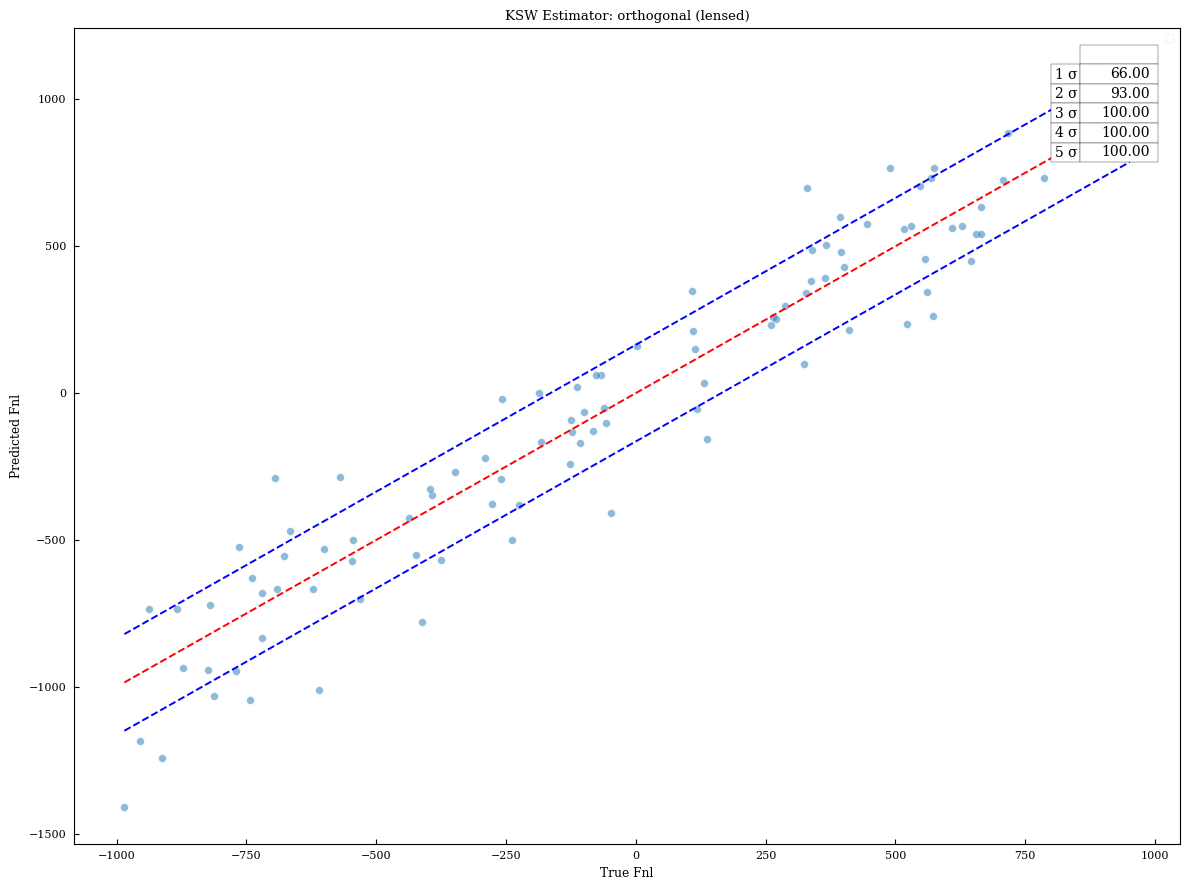

08-Jan-26 12:45:06 - __main__ - INFO - All combinations complete!


In [25]:
from tqdm.auto import tqdm

# Store results for summary
results = {}
pol_idxs = gen.pol_idxs()

for lensed in CONFIG["lensing_options"]:
    lensed_str = "lensed" if lensed else "unlensed"

    for shape_str in tqdm(CONFIG["shapes"], desc=f"{lensed_str}"):
        label = f"{shape_str} ({lensed_str})"
        print(f"\n{'#'*70}")
        print(f"## {label.upper()}")
        print(f"{'#'*70}")

        # 1. Load pre-trained KSW estimator using Generator.get_ksw
        logger.info("Loading KSW estimator for %s...", label)
        ksw = gen.get_ksw(shape_str, lensed=lensed)

        # 2. Generate non-Gaussian alms using Generator methods
        logger.info("Generating non-Gaussian alms for %s...", shape_str)
        if shape_str == "local":
            alm_nl = gen.generate_alm_nl(alm_l)
        else:
            alm_nl = gen.generate_alm_nl_shape(alm_l, shape_str, ksw)

        # 3. Lens if needed using Generator.lens_alms
        if lensed:
            alm_l_use, alm_phi = gen.lens_alms(alm_l)
            alm_nl_use, _ = gen.lens_alms(alm_nl, alm_phi)
        else:
            alm_l_use = alm_l[:, pol_idxs]
            alm_nl_use = alm_nl

        # 4. Combine alms and run estimation
        alm_combined = alm_l_use + fnl_true * alm_nl_use
        print(f"alm_combined shape: {alm_combined.shape}")

        fisher = ksw.compute_fisher()
        sigma = 1.0 / np.sqrt(fisher)
        logger.info("Fisher: %.4f, σ: %.4f", fisher, sigma)

        estimates, _, _, _ = ksw.compute_estimate_batch(
            lambda idx: gen.icov_func(alm_combined[idx], lensed=lensed),
            range(CONFIG["nsims"]),
            fisher=fisher,
        )
        estimates = estimates.T.flatten()
        fnl_flat = fnl_true.flatten()

        # 5. Compute residuals and print statistics
        residuals = estimates - fnl_flat
        print_sigma_stats(residuals, sigma, CONFIG["n_sigma"])

        # 6. Plot predictions
        plot_predictions(
            fnl_flat,
            estimates,
            sigma=sigma,
            title=f"KSW Estimator: {label}",
            show_n_sigma=CONFIG["n_sigma"],
            save=False,
            show=True,
            close=True,
        )

        # Store results
        results[label] = {
            "fisher": fisher,
            "sigma": sigma,
            "mean_residual": np.mean(residuals),
            "std_residual": np.std(residuals),
        }

logger.info("All combinations complete!")

## Summary

Display a summary table of all results.

In [26]:
import pandas as pd

# Create summary DataFrame
summary_data = []
for label, res in results.items():
    summary_data.append(
        {
            "Configuration": label,
            "Fisher": f"{res['fisher']:.4f}",
            "σ": f"{res['sigma']:.4f}",
            "Mean Residual": f"{res['mean_residual']:.4f}",
            "Std Residual": f"{res['std_residual']:.4f}",
        }
    )

df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("SUMMARY OF ALL CONFIGURATIONS")
print("=" * 80)
display(df)


SUMMARY OF ALL CONFIGURATIONS


,Configuration,Fisher,σ,Mean Residual,Std Residual
0,local (unlensed),0.0004,47.2834,3.4619,81.9635
1,equilateral (unlensed),0.0000,309.5494,48.0343,317.1601
2,orthogonal (unlensed),0.0000,164.7939,-0.1513,168.3568
3,local (lensed),0.0004,47.1737,5.8984,105.9454
4,equilateral (lensed),0.0000,309.6725,60.9966,324.2320
5,orthogonal (lensed),0.0000,164.5285,-5.7725,172.1607
